## GNN Lesson 3: Graph Classification with GAT
### What you'll learn
- Graph-level prediction: ONE label per graph (per protein).
- Graph Attention Networks (GAT, Veličković et al. 2018): edges have LEARNED
  weights — neighbours contribute differently based on how relevant the model
  thinks they are. This is "attention", same idea as in transformers.
- Pooling: how to go from per-node features to one per-graph vector
  (global mean-pool / max-pool / sum-pool).

### Compared to lesson 2 (node classification)
- Node classification: one prediction per node.
- Graph classification: one prediction per graph. Need a POOLING step
  to collapse all node features into a single graph-level vector.

### Task
Solubility prediction (binary) on a small subset of DeepSol.
Each protein -> one graph. Each residue -> one node.
Edge structure: sequence-window graph.
Node features: one-hot amino acid identity (in lesson 4 we'll upgrade these
to ESM-2 embeddings).

> **Run order matters.** The cells below build on each other. Run them **top to bottom** (Jupyter: *Run → Run All Cells*; VS Code: *Run All*). If you hit `NameError: name 'torch' is not defined` (or similar), you skipped the **Setup** cell — run it first.

## Setup — imports & configuration

**Run this cell first.** It imports every library and defines the module-level constants the rest of the notebook relies on.

In [1]:
import os
import torch
import torch.nn.functional as F
from datasets import load_dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
DATASET_NAME = "proteinea/solubility"
N_TRAIN = 500
N_TEST = 100
WINDOW = 3
MAX_LEN = 400
HIDDEN = 64
HEADS = 4
EPOCHS = 15
BATCH_SIZE = 8
LR = 5e-4
OUTPUT_DIR = "./results"
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_IDX = {a: i for i, a in enumerate(AMINO_ACIDS)}

In [2]:
# --- MLflow experiment tracking -------------------------------------------
# Import the shared helper regardless of where Jupyter launched from.
# See mlflow_utils.py for the repo-root SQLite backend.
import sys
_root = os.path.abspath("")
for _cand in (_root, os.path.dirname(_root)):
    if os.path.isfile(os.path.join(_cand, "mlflow_utils.py")):
        sys.path.insert(0, _cand); break
import mlflow
import mlflow_utils as mu


### `sequence_to_graph` (function)

Convert a protein sequence + label to a PyG Data object.

In [3]:
def sequence_to_graph(sequence, label, window=WINDOW, max_len=MAX_LEN):
    sequence = sequence[:max_len]  # truncate
    n = len(sequence)

    x = torch.zeros(n, len(AMINO_ACIDS))
    for i, aa in enumerate(sequence):
        if aa in AA_TO_IDX:
            x[i, AA_TO_IDX[aa]] = 1.0

    edges = []
    for i in range(n):
        for d in range(1, window + 1):
            if i + d < n:
                edges.append((i, i + d))
                edges.append((i + d, i))
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))

### `GATGraphClassifier` (class)

Two-layer GAT + global mean pool + linear classifier.

### Why GAT?
A GCN aggregates neighbours with FIXED weights (essentially a normalised
sum). GAT learns ATTENTION coefficients per edge:
    alpha_ij = softmax_j( LeakyReLU(a^T [W h_i || W h_j]) )
    h_i'     = sigma( sum_j alpha_ij * W h_j )
With multiple HEADS, the model learns different "attention patterns" in
parallel and concatenates them — same trick as multi-head attention in
transformers.

### The pooling step
`global_mean_pool(h, batch)` averages all node features within each
graph (as identified by the `batch` tensor) into a single per-graph vector.
Alternatives: global_max_pool, global_add_pool, or a "set transformer".

In [4]:
class GATGraphClassifier(torch.nn.Module):

    def __init__(self, in_channels, hidden, out_channels, heads=4):
        super().__init__()
        # GAT layer 1: project in_channels -> hidden, with `heads` parallel
        # attention heads concatenated (output dim = hidden * heads).
        self.gat1 = GATConv(in_channels, hidden, heads=heads, dropout=0.2)
        # GAT layer 2: combine the heads down to `hidden` (averaging via concat=False).
        self.gat2 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=0.2)
        # Final classifier on the pooled graph vector.
        self.classifier = torch.nn.Linear(hidden, out_channels)

    def forward(self, x, edge_index, batch):
        h = self.gat1(x, edge_index)
        h = F.elu(h)
        h = self.gat2(h, edge_index)
        h = F.elu(h)
        # Pool: (num_nodes_total, hidden) -> (num_graphs_in_batch, hidden)
        g = global_mean_pool(h, batch)
        return self.classifier(g)

### `train_one_epoch` (function)

In [5]:
def train_one_epoch(model, loader, opt, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        opt.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(logits, batch.y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

### `evaluate` (function)

In [6]:
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        pred = logits.argmax(dim=-1)
        correct += (pred == batch.y).sum().item()
        total += batch.num_graphs
    return correct / total

### `main` (function)

In [7]:
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    print(f"Loading dataset: {DATASET_NAME}")
    raw = load_dataset(DATASET_NAME)
    raw = raw.rename_columns({"sequences": "sequence", "labels": "label"})
    raw = raw.map(lambda b: {"label": [int(x) for x in b["label"]]}, batched=True)
    raw = raw.shuffle(seed=42)
    train_raw = raw["train"].select(range(N_TRAIN))
    test_raw = raw["test"].select(range(N_TEST))

    print("Converting sequences to graphs...")
    train_set = [sequence_to_graph(d["sequence"], d["label"]) for d in train_raw]
    test_set = [sequence_to_graph(d["sequence"], d["label"]) for d in test_raw]

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

    # Class balance check
    train_pos = sum(int(d.y.item()) for d in train_set) / len(train_set)
    print(f"  train: {len(train_set)} graphs, pos_frac={train_pos:.3f}")
    print(f"  test:  {len(test_set)} graphs")
    print(f"  Always-predict-majority test accuracy: {max(train_pos, 1 - train_pos):.3f}")

    model = GATGraphClassifier(
        in_channels=len(AMINO_ACIDS), hidden=HIDDEN, out_channels=2, heads=HEADS
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

    print("\nTraining...")
    for ep in range(EPOCHS):
        loss = train_one_epoch(model, train_loader, opt, device)
        acc = evaluate(model, test_loader, device)
        print(f"  epoch {ep + 1:3d}  loss={loss:.3f}  test_acc={acc:.3f}")

    final_acc = evaluate(model, test_loader, device)
    print(f"\nFinal test accuracy: {final_acc:.3f}")

    with mu.run("gnn-graph-classification", "l3_gat_onehot",
                params={"dataset": DATASET_NAME, "model": "GAT", "features": "one-hot",
                        "n_train": N_TRAIN, "n_test": N_TEST, "window": WINDOW,
                        "hidden": HIDDEN, "heads": HEADS, "epochs": EPOCHS,
                        "batch_size": BATCH_SIZE, "lr": LR},
                tags={"lesson": "gnn_l3", "model": "GAT", "features": "one-hot"}):
        mlflow.log_metrics({"test_acc": float(final_acc),
                            "majority_acc": float(max(train_pos, 1 - train_pos))})

    print(
        """
Things to experiment with:
- Increase WINDOW to 5 or 7 — wider edges = larger receptive field.
- Replace GAT with GCNConv or SAGEConv — see how attention compares.
- Replace global_mean_pool with global_max_pool or global_add_pool.
- Add a third GAT layer (might overfit on this dataset size — try with dropout).
- For fairer evaluation, add early stopping on a validation split.
- Lesson 4 keeps everything else the same and swaps node features
  to ESM-2 embeddings — the typical accuracy bump is large.
"""
    )

## Run the lesson

Execute everything above, then run `main()`.

In [8]:
main()

Using device: cuda
Loading dataset: proteinea/solubility


Converting sequences to graphs...


  train: 500 graphs, pos_frac=0.412
  test:  100 graphs
  Always-predict-majority test accuracy: 0.588

Training...


  epoch   1  loss=0.679  test_acc=0.520


  epoch   2  loss=0.678  test_acc=0.520


...

  epoch  12  loss=0.664  test_acc=0.510


  epoch  13  loss=0.661  test_acc=0.520


  epoch  14  loss=0.660  test_acc=0.560


  epoch  15  loss=0.661  test_acc=0.600

Final test accuracy: 0.600



Things to experiment with:
- Increase WINDOW to 5 or 7 — wider edges = larger receptive field.
- Replace GAT with GCNConv or SAGEConv — see how attention compares.
- Replace global_mean_pool with global_max_pool or global_add_pool.
- Add a third GAT layer (might overfit on this dataset size — try with dropout).
- For fairer evaluation, add early stopping on a validation split.
- Lesson 4 keeps everything else the same and swaps node features
  to ESM-2 embeddings — the typical accuracy bump is large.



## Beyond the accuracy number: which proteins, and versus what?

`main()` prints a single number. Here we **keep** the trained GAT and ask two sharper questions:

1. **Does the graph actually help**, or could a plain *bag of amino acids* do just as well? We add an amino-acid-composition baseline (mean one-hot features → logistic regression) that sees the same residues but **no edges and no order**.
2. **Which specific proteins** does the GAT classify correctly that the baseline gets wrong?

In [9]:
import numpy as np
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# Rebuild the exact data main() used — but KEEP the model this time
# (main() trains then discards it).
raw = load_dataset(DATASET_NAME)
raw = raw.rename_columns({"sequences": "sequence", "labels": "label"})
raw = raw.map(lambda b: {"label": [int(x) for x in b["label"]]}, batched=True)
raw = raw.shuffle(seed=42)
train_raw = raw["train"].select(range(N_TRAIN))
test_raw = raw["test"].select(range(N_TEST))
train_set = [sequence_to_graph(d["sequence"], d["label"]) for d in train_raw]
test_set = [sequence_to_graph(d["sequence"], d["label"]) for d in test_raw]
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

torch.manual_seed(0)
gat = GATGraphClassifier(len(AMINO_ACIDS), HIDDEN, 2, HEADS).to(device)
opt = torch.optim.Adam(gat.parameters(), lr=LR, weight_decay=1e-4)
for ep in range(EPOCHS):
    train_one_epoch(gat, train_loader, opt, device)
gat_acc = evaluate(gat, test_loader, device)
print(f"GAT (attention + message passing) test accuracy = {gat_acc:.3f}")

GAT (attention + message passing) test accuracy = 0.540


### Baseline: amino-acid composition (no graph)

The fairest "does message passing actually matter?" baseline: collapse each protein to its 20-dim amino-acid frequency vector and fit a logistic regression. It sees the *same residues* as the GAT but with **no edges and no order**.

In [10]:
from sklearn.linear_model import LogisticRegression


# Baseline: amino-acid COMPOSITION only — the mean of the one-hot node
# features per protein (a 20-dim amino-acid frequency vector). No edges, no
# order, no message passing. "Bag of amino acids."
def composition(d):
    return d.x.mean(dim=0).numpy()


Xtr = np.stack([composition(d) for d in train_set])
ytr = np.array([int(d.y) for d in train_set])
Xte = np.stack([composition(d) for d in test_set])
yte = np.array([int(d.y) for d in test_set])

clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
base_acc = clf.score(Xte, yte)
majority = max(ytr.mean(), 1 - ytr.mean())

print(f"Majority-class baseline       = {majority:.3f}")
print(f"AA-composition LR (no graph)  = {base_acc:.3f}")
print(f"GAT (uses the graph)          = {gat_acc:.3f}")

Majority-class baseline       = 0.588
AA-composition LR (no graph)  = 0.520
GAT (uses the graph)          = 0.540


### Specific proteins where the graph wins

These are test proteins the GAT predicted **correctly** while the composition baseline got them **wrong** — cases where reasoning over residue neighbourhoods (not just counting amino acids) flipped the answer to the right one. `conf` is the GAT's softmax probability for its predicted class.

In [11]:
gat.eval()
gat_pred, gat_conf = [], []
with torch.no_grad():
    for d in test_set:
        b = torch.zeros(d.num_nodes, dtype=torch.long, device=device)
        logits = gat(d.x.to(device), d.edge_index.to(device), b)
        p = F.softmax(logits, dim=-1)[0]
        gat_pred.append(int(p.argmax()))
        gat_conf.append(float(p.max()))
gat_pred = np.array(gat_pred)
base_pred = clf.predict(Xte)

LAB = {0: "insoluble", 1: "soluble"}
wins = [i for i in range(len(test_set))
        if gat_pred[i] == yte[i] and base_pred[i] != yte[i]]

print(f"{len(wins)} test proteins the GAT got RIGHT but the AA-composition "
      f"baseline got WRONG.\n")
print(f"{'#':>3} {'len':>4} {'true':>10} {'GAT pred':>10} {'conf':>5} {'baseline':>10}")
print("-" * 52)
for i in wins[:10]:
    L = len(test_raw[i]["sequence"][:MAX_LEN])
    print(f"{i:>3} {L:>4} {LAB[yte[i]]:>10} {LAB[gat_pred[i]]:>10} "
          f"{gat_conf[i]:>5.2f} {LAB[base_pred[i]]:>10}")

if not wins:
    print("(None this run — on a 100-protein test set the two can tie. "
          "Re-run, or raise N_TRAIN/N_TEST.)")

4 test proteins the GAT got RIGHT but the AA-composition baseline got WRONG.



  #  len       true   GAT pred  conf   baseline
----------------------------------------------------
 14  243    soluble    soluble  0.51  insoluble
 35   80    soluble    soluble  0.50  insoluble
 36  400    soluble    soluble  0.51  insoluble
 96   61    soluble    soluble  0.59  insoluble


### The headline, with both baselines

Test accuracy against (a) always predicting the majority class and (b) the amino-acid-composition logistic regression. The gap between the orange and blue bars is what message passing + attention bought us *over the same residues with no graph*.

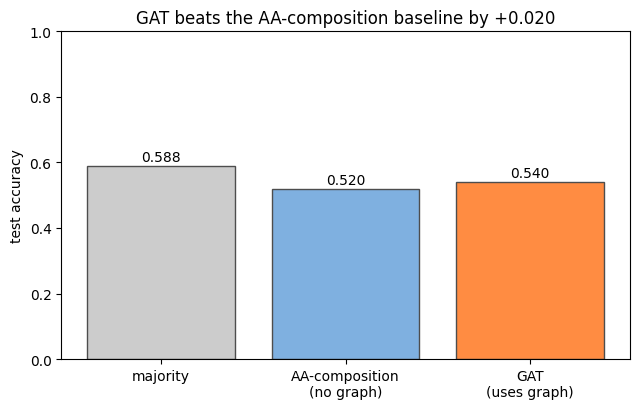

In [12]:
import matplotlib.pyplot as plt

names = ["majority", "AA-composition\n(no graph)", "GAT\n(uses graph)"]
vals = [majority, base_acc, gat_acc]
colors = ["#cccccc", "#7fb0e0", "#ff8c42"]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(names, vals, color=colors, edgecolor="0.3")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.006, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("test accuracy")
ax.set_ylim(0, 1.0)
ax.set_title(f"GAT beats the AA-composition baseline by {gat_acc - base_acc:+.3f}")
plt.tight_layout()
plt.show()